# Assignment 4: Decision Tree Model and Business Interpretation

**Business Case:** FreshBasket Subscription Grocery Delivery  
**Topic:** Customer Churn Prediction and Retention Decision Support  
**Model:** Decision Tree Classifier

## Assignment Goal
The goal of this assignment is to build a Decision Tree classification model using the FreshBasket customer churn dataset and explain the model results from a business perspective. The notebook connects the technical model results to business decisions such as customer retention, support follow-up, discount targeting, and service improvement.

## Task 1: Understand the Business Problem

### What is the business about?
FreshBasket is a subscription based grocery delivery service operating in the Greater Toronto Area. The company offers weekly and monthly grocery delivery plans for busy professionals, families, and customers who prefer convenient online grocery ordering. FreshBasket earns revenue from recurring subscription fees and regular grocery orders.

### What problem is the business trying to solve?
The main business problem is customer churn. Customer churn happens when customers cancel or do not renew their subscription. This is important because FreshBasket depends on repeat customers. When customers leave, the business loses recurring revenue and may need to spend more money to attract new customers.

### What decision can machine learning help the business make?
Machine learning can help FreshBasket predict which customers are likely to churn. This prediction can help managers decide which customers should receive retention attention, such as customer support, personalized discounts, service recovery messages, or a better subscription recommendation.

### What is the target variable?
The target variable is **Churned**.

- **Yes** means the customer churned.
- **No** means the customer did not churn.

### What are the input features?
The input features include customer demographics, subscription details, payment method, delivery window, membership length, monthly spending, average order value, recent orders, delivery issues, customer service tickets, discount use, app engagement, and satisfaction score.

### Why is this prediction useful for the business?
This prediction is useful because it helps FreshBasket identify 'at risk' customers before they leave. The business can use the model to reduce revenue loss, improve retention campaigns, prioritize customer support, and understand which customer experience factors are most connected to churn.

## Task 2: Prepare the Data

This section loads the dataset, inspects its structure, checks missing values and duplicates, cleans the data, separates features and target variable, handles categorical and numerical variables, and splits the dataset into training and testing sets.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Show all columns clearly
pd.set_option('display.max_columns', None)

### Confusion Matrix Interpretation in Simple Words

The confusion matrix gives a more detailed view of the model's correct and incorrect predictions.

Using the testing dataset, the model produced the following results:

- **33 customers** were correctly predicted as **No Churn**. These are customers who actually stayed and were correctly classified as staying.
- **18 customers** were correctly predicted as **Churn**. These are customers who actually left and were successfully identified by the model.
- **28 customers** were incorrectly predicted as **Churn**, even though they actually stayed. These are false positives.
- **5 customers** were incorrectly predicted as **No Churn**, even though they actually churned. These are false negatives.

From a business perspective, the model is useful because it correctly identified **18 out of 23 actual churned customers**, which gives a strong recall result. This means FreshBasket would catch many customers who are truly at risk of leaving. However, the model also creates many false positives, meaning some customers may receive retention attention even though they would have stayed anyway. This is a reasonable trade-off for a churn problem because missing actual churned customers can lead to lost recurring revenue.

In [2]:
# Load the dataset
file_path = "freshbasket_customer_churn_dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="Dataset")

# Display the first five rows
df.head()

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,Customer_ID,Age_Group,Region,Subscription_Type,Payment_Method,Delivery_Window,Membership_Length_Months,Monthly_Spend,Average_Order_Value,Orders_Last_3_Months,Delivery_Issues_Last_3_Months,Customer_Service_Tickets,Discount_Used,App_Engagement_Score,Satisfaction_Score,Churned
0,FB-1001,18-24,Toronto,Family,Credit Card,Evening,18,267.23,140.14,9,0,0,No,70.0,3.0,No
1,FB-1002,45-54,Toronto,Premium,Credit Card,Morning,7,349.36,179.20,10,1,1,No,14.0,3.0,Yes
2,FB-1003,35-44,Mississauga,Basic,Credit Card,Morning,4,132.08,25.00,6,0,0,Yes,46.0,3.0,No
3,FB-1004,35-44,Ajax,Basic,Credit Card,Afternoon,8,80.71,25.00,0,1,0,Yes,42.0,5.0,Yes
4,FB-1005,45-54,Markham,Family,Credit Card,Morning,21,218.95,31.10,1,0,0,No,88.0,3.0,No


In [3]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset shape: (425, 16)
Rows: 425
Columns: 16


In [4]:
# Inspect column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    425 non-null    object 
 1   Age_Group                      425 non-null    object 
 2   Region                         416 non-null    object 
 3   Subscription_Type              425 non-null    object 
 4   Payment_Method                 425 non-null    object 
 5   Delivery_Window                425 non-null    object 
 6   Membership_Length_Months       425 non-null    int64  
 7   Monthly_Spend                  419 non-null    float64
 8   Average_Order_Value            425 non-null    float64
 9   Orders_Last_3_Months           425 non-null    int64  
 10  Delivery_Issues_Last_3_Months  425 non-null    int64  
 11  Customer_Service_Tickets       425 non-null    int64  
 12  Discount_Used                  425 non-null    obj

In [5]:
# Check missing values in each column
missing_values = df.isnull().sum()
missing_values

Customer_ID                      0
Age_Group                        0
Region                           9
Subscription_Type                0
Payment_Method                   0
Delivery_Window                  0
Membership_Length_Months         0
Monthly_Spend                    6
Average_Order_Value              0
Orders_Last_3_Months             0
Delivery_Issues_Last_3_Months    0
Customer_Service_Tickets         0
Discount_Used                    0
App_Engagement_Score             4
Satisfaction_Score               6
Churned                          0
dtype: int64

In [6]:
# Check duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 5


In [7]:
# Check target variable distribution
print(df["Churned"].value_counts())
print("Target distribution percentage:")
print(round(df["Churned"].value_counts(normalize=True) * 100, 2))

Churned
No     307
Yes    118
Name: count, dtype: int64
Target distribution percentage:
Churned
No     72.24
Yes    27.76
Name: proportion, dtype: float64


### Target Distribution and Class Imbalance Interpretation

The target distribution shows that the dataset is somewhat imbalanced because there are more non-churned customers than churned customers. In the original dataset, about **72.2%** of customers are labeled **No Churn**, while about **27.8%** are labeled **Churn**.

In simple words, the model sees more examples of customers who stayed than customers who left. This matters because a model can sometimes look accurate by predicting the majority class more often. For a churn prediction problem, this is a limitation because the business is especially interested in identifying the smaller churn group. For this reason, recall and F1-score are important alongside accuracy.

### Data Cleaning Plan

- Removing duplicate rows, if present.
- The `Customer_ID` column will be removed because it is an identifier, not a useful prediction feature.
- Missing categorical values will be filled using the most frequent value.
- Missing numerical values will be filled using the median.
- Categorical variables will be converted into numerical form using one-hot encoding.
- The target variable `Churned` will be converted into binary values: `Yes = 1` and `No = 0`

In [8]:
# Removing duplicate rows
before_rows = df.shape[0]
df_clean = df.drop_duplicates().copy()
after_rows = df_clean.shape[0]

print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before removing duplicates: 425
Rows after removing duplicates: 420
Rows removed: 5


In [9]:
# Separating features and target variable
# Customer_ID is removed because it is only an ID and should not be used for prediction.
X = df_clean.drop(columns=["Customer_ID", "Churned"])
y = df_clean["Churned"]

# Convert target to binary values
# Yes = churned customer, No = retained customer
y = y.map({"No": 0, "Yes": 1})

print("Feature columns:")
print(X.columns.tolist())
print("Target preview:")
print(y.head())

Feature columns:
['Age_Group', 'Region', 'Subscription_Type', 'Payment_Method', 'Delivery_Window', 'Membership_Length_Months', 'Monthly_Spend', 'Average_Order_Value', 'Orders_Last_3_Months', 'Delivery_Issues_Last_3_Months', 'Customer_Service_Tickets', 'Discount_Used', 'App_Engagement_Score', 'Satisfaction_Score']
Target preview:
0    0
1    1
2    0
3    1
4    0
Name: Churned, dtype: int64


In [10]:
# Identifying categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Age_Group', 'Region', 'Subscription_Type', 'Payment_Method', 'Delivery_Window', 'Discount_Used']
Numerical features: ['Membership_Length_Months', 'Monthly_Spend', 'Average_Order_Value', 'Orders_Last_3_Months', 'Delivery_Issues_Last_3_Months', 'Customer_Service_Tickets', 'App_Engagement_Score', 'Satisfaction_Score']


In [11]:
# Splitting the data into training and testing sets
# Stratify is used so the churn/no-churn class balance is similar in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (336, 14)
X_test shape: (84, 14)
y_train distribution:
Churned
0    243
1     93
Name: count, dtype: int64
y_test distribution:
Churned
0    61
1    23
Name: count, dtype: int64


In [12]:
# Preprocessing for categorical and numerical variables
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))])

preprocessor = ColumnTransformer(transformers=[
    ("categorical", categorical_transformer, categorical_features),
    ("numerical", numerical_transformer, numerical_features)])

## Task 3: Train a Decision Tree Classification Model

A Decision Tree Classifier is used because it is easy to interpret and can show which customer factors are most important in predicting churn.

The model uses:

- `max_depth=5` to prevent the tree from becoming too complex.
- `min_samples_leaf=8` to avoid making decisions based on very small groups of customers.
- `class_weight="balanced"` because the dataset has more non-churn customers than churn customers. This helps the model pay more attention to churned customers.

In [13]:
# Building the Decision Tree model pipeline
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        min_samples_leaf=8,
        class_weight="balanced"))])

# Training the model
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Age_Group', 'Region',
                                                   'Subscription_Type',
                                                   'Payment_Method',
                                                   'Delivery_Window',
                                                   'Discount_Used']),
                                                 ('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Membership_Length_Months',
                                                   'Monthly_Spend',
                                                   'Average_Order_Value',
                                                   'Orders_Last_3_Months',
                                                   'Delivery_Issues_Last_3_Months',
                                                   'Customer_Service_Tickets',
                                                   'App_Engagement_Score',
                                                   'Satisfaction_Score'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=8, random_state=42))])

In [14]:
# Making predictions
y_train_pred = decision_tree_model.predict(X_train)
y_test_pred = decision_tree_model.predict(X_test)

# Calculating model performance metrics
training_accuracy = accuracy_score(y_train, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Training Accuracy:", round(training_accuracy, 3))
print("Testing Accuracy:", round(testing_accuracy, 3))
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))

Training Accuracy: 0.664
Testing Accuracy: 0.607
Accuracy: 0.607
Precision: 0.391
Recall: 0.783
F1-score: 0.522


Confusion Matrix:
[[33 28]
 [ 5 18]]


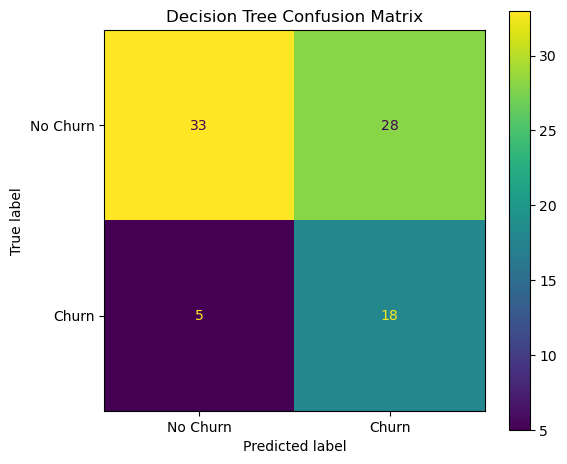

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

# Display confusion matrix as a chart
fig, ax = plt.subplots(figsize=(6, 5))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"])
display.plot(ax=ax, values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Classification report
print(classification_report(y_test, y_test_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.87      0.54      0.67        61
       Churn       0.39      0.78      0.52        23

    accuracy                           0.61        84
   macro avg       0.63      0.66      0.59        84
weighted avg       0.74      0.61      0.63        84



### Overfitting Check

Overfitting happens when a model performs very well on training data but performs much worse on testing data. In this assignment, overfitting is checked by comparing training accuracy and testing accuracy.

In [17]:
# Comparing training and testing accuracy
overfitting_gap = training_accuracy - testing_accuracy

print("Training Accuracy:", round(training_accuracy, 3))
print("Testing Accuracy:", round(testing_accuracy, 3))
print("Difference:", round(overfitting_gap, 3))

if overfitting_gap > 0.10:
    print("The model may be overfitting because the training accuracy is much higher than the testing accuracy.")
else:
    print("The model does not show strong overfitting because the training and testing accuracy are reasonably close.")

Training Accuracy: 0.664
Testing Accuracy: 0.607
Difference: 0.057
The model does not show strong overfitting because the training and testing accuracy are reasonably close.


## Feature Importance

Feature importance helps explain which variables had the greatest influence on the Decision Tree model. This is useful for business managers because it shows which customer factors may be most connected to churn risk.

In [18]:
# Getting feature names after preprocessing
encoded_feature_names = decision_tree_model.named_steps["preprocessor"].get_feature_names_out()

# Getting feature importance values
importance_values = decision_tree_model.named_steps["model"].feature_importances_

# Creating feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importance_values
}).sort_values(by="Importance", ascending=False)

# Display top 15 important features
feature_importance.head(15)

,Feature,Importance
31,numerical__Satisfaction_Score,0.344042
25,numerical__Monthly_Spend,0.260618
27,numerical__Orders_Last_3_Months,0.160322
30,numerical__App_Engagement_Score,0.096783
26,numerical__Average_Order_Value,0.066081
10,categorical__Region_Toronto,0.057204
29,numerical__Customer_Service_Tickets,0.014950
17,categorical__Payment_Method_Debit Card,0.000000
28,numerical__Delivery_Issues_Last_3_Months,0.000000
24,numerical__Membership_Length_Months,0.000000


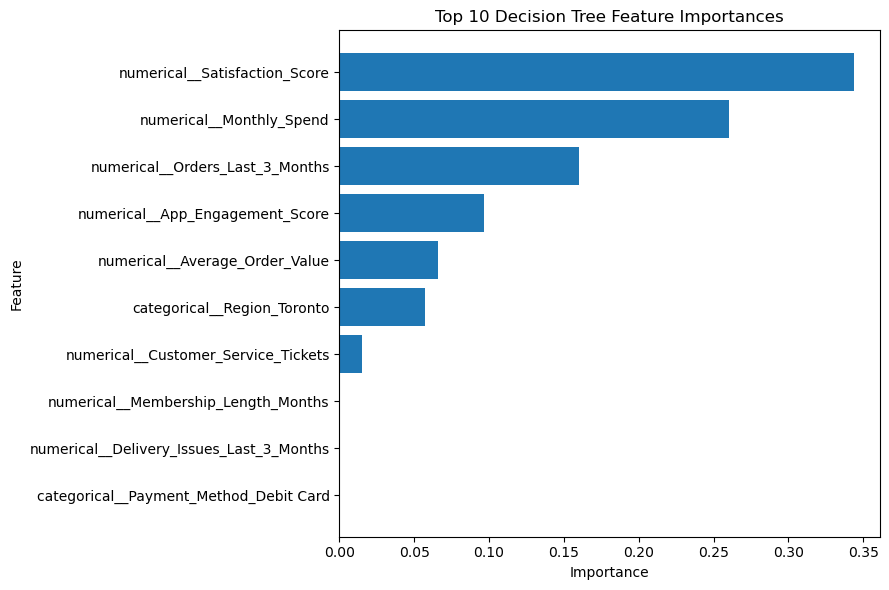

In [19]:
# Plotting top 10 feature importances
top_features = feature_importance.head(10).sort_values(by="Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Decision Tree Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()